In [2]:
using CMPSKit, Plots, LaTeXStrings, OptimKit, KrylovKit, LinearAlgebra

In [ ]:
# Local densities:
n̂ = ψ̂' * ψ̂; # particle density operator
k̂ = ∂ψ̂' * ∂ψ̂; # kinetic energy density operator
û = (ψ̂')^2 * ψ̂^2; # interaction operator

H(; c, μ) = ∫(k̂ - μ * n̂ + c * û, (-Inf, +Inf));

find_groundstate (generic function with 1 method)

In [5]:
c, μ = 10., 5.
tol = 1e-10
hamiltonian = H(c=c, μ=μ)
hamiltonian_density = CMPSKit.density(hamiltonian)

Ds = [4, 8, 12]
state = find_groundstate(Ds, hamiltonian, optalg=LBFGS(80; verbosity=1, maxiter=7000, gradtol=tol), gradtol=tol)
D = maximum(Ds)
state.Rs[1][] ./= (state.Rs[1][][1] / norm(state.Rs[1][][1])) # fix phase
ρ = expval(n̂, state)[]

println("Energy density: ", expval(hamiltonian_density, state)[], "\n Particle density: ", expval(n̂, state)[], "\n Order parameter: ", expval(ψ̂, state)[])

Optimizing D=4


┌ Warning: The function `inner` is not implemented for (values of) type `Tuple{Constant{Matrix{Float64}}, Constant{Matrix{Float64}}}`;
│ this fallback will disappear in future versions of VectorInterface.jl
└ @ VectorInterface /home/ashankar/.julia/packages/VectorInterface/J6qCR/src/fallbacks.jl:196
┌ Warning: The function `scale` is not implemented for (values of) type `Tuple{Constant{Matrix{Float64}}, Float64}`;
│ this fallback will disappear in future versions of VectorInterface.jl
└ @ VectorInterface /home/ashankar/.julia/packages/VectorInterface/J6qCR/src/fallbacks.jl:67
┌ Warning: The function `add!!` is not implemented for (values of) type `Tuple{Constant{Matrix{Float64}}, Constant{Matrix{Float64}}, Float64, VectorInterface.One}`;
│ this fallback will disappear in future versions of VectorInterface.jl
└ @ VectorInterface /home/ashankar/.julia/packages/VectorInterface/J6qCR/src/fallbacks.jl:163
┌ Warning: The function `scalartype` is not implemented for (values of) type `Constant

 15.732683 seconds (27.44 M allocations: 1.335 GiB, 1.73% gc time, 99.23% compilation time: <1% of which was recompilation)
---------------
Optimizing D=8


┌ Info: UniformCMPS ground state: initialization with e = -2.761265509078
└ @ CMPSKit /home/ashankar/Documents/PhDstuff/code/TensorNetworks/CMPSKit.jl/src/infinitecmps/groundstate.jl:115
┌ Info: UniformCMPS ground state: converged after 414 iterations: e = -2.764113438366, ‖∇e‖ = 9.7112e-11
└ @ CMPSKit /home/ashankar/Documents/PhDstuff/code/TensorNetworks/CMPSKit.jl/src/infinitecmps/groundstate.jl:127


  6.706242 seconds (4.02 M allocations: 368.730 MiB, 1.64% gc time, 7.19% compilation time)
---------------
Optimizing D=12
 36.580602 seconds (8.62 M allocations: 1.427 GiB, 0.76% gc time)
---------------
Energy density: -2.7641134383656984
 Particle density: 0.8737724721037234
 Order parameter: 0.4641646054707857


In [5]:
nvals = 20

ps = range(0π * ρ, 4π * ρ, 30)
trivial_spectrum = zeros(ComplexF64, length(ps), nvals);

Threads.@threads for idx in eachindex(ps)
    space = InfiniteCMPSExcitationSpace(ps[idx], state, state)
    Heff = excitation_operator(hamiltonian, space)
    trivial_spectrum[idx, :] .= eigsolve(Heff, (Constant(rand(ComplexF64, size(state.Q[]))),), nvals, :SR)[1][1:nvals]
    # println("Finished $idx - $(ps[idx])")
end

┌ Warning: The function `add` is not implemented for (values of) type `Tuple{Constant{Matrix{ComplexF64}}, Constant{Matrix{ComplexF64}}, ComplexF64, ComplexF64}`;
│ this fallback will disappear in future versions of VectorInterface.jl
└ @ VectorInterface C:\Users\saksh\.julia\packages\VectorInterface\J6qCR\src\fallbacks.jl:131


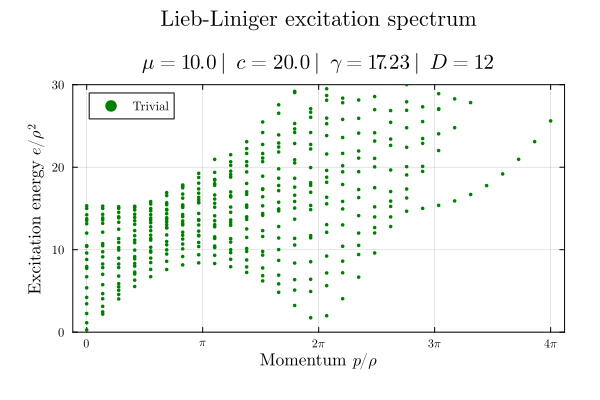

In [6]:
scatter(ps ./ ρ, real.(trivial_spectrum) ./ ρ^2, ylims=[0, 30], lab=permutedims(["Trivial"; fill("", nvals - 1)]), ms=2, c=:green, markerstrokewidth=0)
plot!(xtick=pitick(0, 4π, 1, mode=:latex), ylabel="Excitation energy " * L"e/\rho^2", xlabel="Momentum " * L"p/\rho", title="Lieb-Liniger excitation spectrum\n\n" * L"\mu=%$(μ) \ | \ c=%$(c) \ | \ \gamma = %$(round(c/ρ, digits=3))\ | \ D=%$(D)", margins=7Plots.mm)

In [6]:
nvals = 10
pts = range(-2π * ρ, 2π * ρ, 30)
topological_spectrum = zeros(ComplexF64, length(pts), nvals);
topological_excitations = [[zeros(ComplexF64, size(state.Q[])) for _ in 1:nvals] for _ in eachindex(pts)]
u1charges = zeros(ComplexF64, length(pts), nvals)

ρr = rightenv(state)[1][]
theta = π
state = InfiniteCMPS(Constant(ComplexF64.(state.Q[])), Constant(ComplexF64.(state.Rs[1][])))
state_alt = InfiniteCMPS(state.Q, exp(1im * theta) * state.Rs[1])

Threads.@threads for idx in eachindex(pts)
    space = InfiniteCMPSExcitationSpace(pts[idx], state, state_alt)
    Heff = excitation_operator(hamiltonian, space)
    vals, vecs, _ = eigsolve(Heff, (Constant(rand(ComplexF64, size(state.Q[]))),), nvals, :SR)
    topological_spectrum[idx, :] .= vals[1:nvals]
    topological_excitations[idx] .= getindex.(getindex.(vecs[1:nvals], 1))

    for (i, W) in enumerate(topological_excitations[idx])
        # ∫⟨ρ⟩ - ⟨ρ₀⟩ = N -> particle/hole charge
        Hψ = excitation_operator(∫(ψ̂' * ψ̂, (-Inf, Inf)), space)
        ψW = Hψ((Constant(W),))[1][]
        u1charges[idx, i] = tr(ψW * ρr * W')
    end
    # println("Finished $idx - $(pts[idx])")
end

┌ Warning: The function `add` is not implemented for (values of) type `Tuple{Constant{Matrix{ComplexF64}}, Constant{Matrix{ComplexF64}}, ComplexF64, ComplexF64}`;
│ this fallback will disappear in future versions of VectorInterface.jl
└ @ VectorInterface /home/ashankar/.julia/packages/VectorInterface/J6qCR/src/fallbacks.jl:131


In [ ]:
topological_spectrum

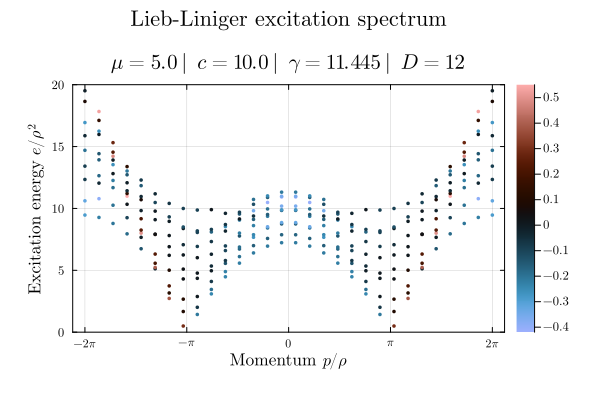

In [7]:
scatter(pts ./ ρ, real.(topological_spectrum) ./ ρ^2, ylims=[0, 20], lab=permutedims([""; fill("", nvals - 1)]), ms=2., marker_z=real.(u1charges), markerstrokewidth=0, colorbar=true, c=:berlin)
plot!(xtick=pitick(-2π, 2π, 1, mode=:latex), ylabel="Excitation energy " * L"e/\rho^2", xlabel="Momentum " * L"p/\rho", title="Lieb-Liniger excitation spectrum\n\n" * L"\mu=%$(μ) \ | \ c=%$(c) \ | \ \gamma = %$(round(c/ρ, digits=3))\ | \ D=%$(D)", margins=7Plots.mm)

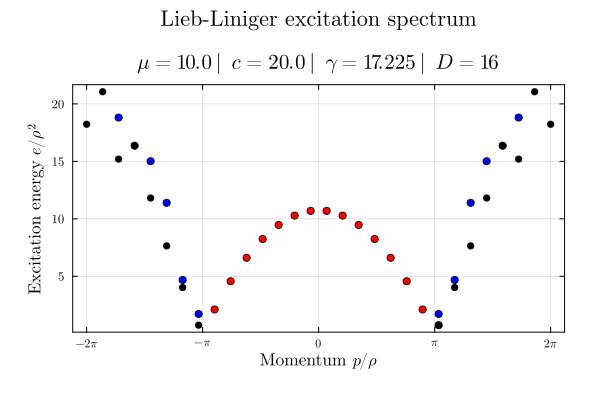

In [51]:
begin
    domain_idx = [searchsortedfirst(pts, -π * ρ), searchsortedfirst(pts, π * ρ)]
    # lowest energy in -πρ ≤ p ≤ πρ
    hole_spectrum = real.(topological_spectrum[domain_idx[1]:domain_idx[2], 1])

    # positive particle number wrt ground state
    particle_spectrum = map(1:size(u1charges, 1)) do rowidx
        idx = findlast(>(0), real.(u1charges)[rowidx, :])
        isnothing(idx) && return missing
        real(topological_spectrum[rowidx, idx])
    end

    # largest overlap with fermionic particle excitation in TG limit
    overlaps = zeros(ComplexF64, length(pts), nvals)

    Threads.@threads for idx in eachindex(pts)
        p = pts[idx]
        Q, R = state.Q[], state.Rs[1][]
        X, _ = linsolve(-R') do X
            R' * (X * R - R * X) + (X * Q - Q * X) + 1im * p * X
        end

        Wp = I + X * R - R * X
        # Wp = I

        overlaps[idx, :] .= abs.(tr.(topological_excitations[idx] .* Ref(ρr * Wp')))
    end

    particle_spectrum_alt = map(1:size(u1charges, 1)) do rowidx
        ((rowidx >= domain_idx[1]) && (rowidx < domain_idx[2])) && return missing
        # overlaps is generally complex.. should it be?
        idx = argmax(real.(overlaps)[rowidx, :])
        real(topological_spectrum[rowidx, idx])
    end

    scatter(pts[domain_idx[1]:domain_idx[2]] ./ ρ, hole_spectrum, c=:red)
    scatter!(pts ./ ρ, particle_spectrum, c=:blue)
    scatter!(pts ./ ρ, particle_spectrum_alt, c=:black)
    plot!(xtick=pitick(-2π, 2π, 1, mode=:latex), ylabel="Excitation energy " * L"e/\rho^2", xlabel="Momentum " * L"p/\rho", title="Lieb-Liniger excitation spectrum\n\n" * L"\mu=%$(μ) \ | \ c=%$(c) \ | \ \gamma = %$(round(c/ρ, digits=3))\ | \ D=%$(D)", margins=7Plots.mm)
end

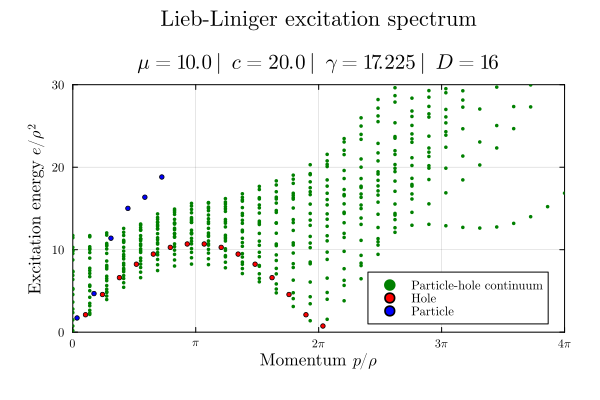

In [ ]:
scatter(ps ./ ρ, real.(trivial_spectrum) ./ ρ^2, ylims=[0, 30], lab=permutedims(["Particle-hole continuum"; fill("", nvals + 10)]), ms=2, c=:green, markerstrokewidth=0)
scatter!(pts[domain_idx[1]:domain_idx[2]] ./ ρ .+ π, hole_spectrum, c=:red, ms=2.5, lab="Hole")
scatter!(pts ./ ρ .- π, particle_spectrum, c=:blue, ms=2.5, lab="Particle")
plot!(xtick=pitick(0, 4π, 1, mode=:latex), ylabel="Excitation energy " * L"e/\rho^2", xlabel="Momentum " * L"p/\rho", title="Lieb-Liniger excitation spectrum\n\n" * L"\mu=%$(μ) \ | \ c=%$(c) \ | \ \gamma = %$(round(c/ρ, digits=3))\ | \ D=%$(D)", margins=7Plots.mm, xlims=[0, 4π])

In [25]:
# let 
#     number_conserving_excitations = map(1:size(u1charges, 1)) do rowidx
#         idx = argmin(abs.(u1charges[rowidx, :]))
#         real(topological_spectrum[rowidx, idx])
#     end

#     scatter(pts, number_conserving_excitations, c=:black)
# end

In [ ]:
# Bogoliubov phonon
# scatter(ps ./ ρ, real.(trivial_spectrum) ./ ρ^2)
# plot!(k -> sqrt(k^4 + c / ρ * k^2), range(first(ps), last(ps), 100) ./ ρ) # bogoliubov

In [74]:
begin
    ΨL, _, CL = leftgauge(state)
    ΨR, _, CR = rightgauge(state)
    C = CL * CR
    CMPSKit.centergradient(hamiltonian, (ΨL, ΨR, C))[3] |> norm
end

1.3436351917319677e-10